# Очистка и подготовка данных

Цель: привести типы, сохранить наблюдения, консервативно учесть подтверждаемые отмены/возвраты и собрать таблицу `клиент × неделя` для анализа связи заправок и штрафов. Сырые CSV не изменяются.

In [66]:
from pathlib import Path

import pandas as pd
from IPython.display import display

from preprocessing import (
    FINES_HISTORY_COLUMNS, PAIR_KEYS, build_cleaning_report, clean_fuel_data,
    load_clients_data, load_fuel_data, resolve_client_auto_duplicates,
    resolve_field_conflict, save_cleaning_outputs, validate_cleaned_data,
)

OUTPUT_DIR = Path("data/processed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

START_DATE = pd.Timestamp("2026-04-01")
END_DATE = pd.Timestamp("2026-08-31 23:59:59")
CRISIS_START = pd.Timestamp("2026-06-01")

## 1. Загрузка данных

In [67]:
clients = load_clients_data("clients_demographics.csv")
fines = pd.read_csv(
    "fines_2026.csv", sep=";", decimal=",", encoding="utf-8",
    dtype={column: "string" for column in ["client_id", "bill_id", "auto_document_id"]},
)
fuel = load_fuel_data("fuel_transaction.csv")

print("Клиенты:", clients.shape)
print("Штрафы:", fines.shape)
print("Заправки:", fuel.shape)

Клиенты: (28237, 20)
Штрафы: (77978, 7)
Заправки: (379699, 5)


## Проверка идентификаторов и связей

Уникальность проверяется относительно уровня каждой таблицы: постановление, транзакция или пара клиент–автомобиль.

In [68]:
id_audit = pd.DataFrame([
    ["clients", "client_id", len(clients), clients["client_id"].nunique(), clients["client_id"].isna().sum(), clients.duplicated("client_id").sum(), "не обязан: у клиента несколько авто"],
    ["clients", "client_id + auto_document_id", len(clients), clients[["client_id", "auto_document_id"]].drop_duplicates().shape[0], clients[["client_id", "auto_document_id"]].isna().any(axis=1).sum(), clients.duplicated(["client_id", "auto_document_id"]).sum(), "должен быть уникален после агрегации"],
    ["fines", "bill_id", len(fines), fines["bill_id"].nunique(), fines["bill_id"].isna().sum(), fines.duplicated("bill_id").sum(), "должен быть уникален"],
    ["fuel", "order_id", len(fuel), fuel["order_id"].nunique(), fuel["order_id"].isna().sum(), fuel.duplicated("order_id").sum(), "должен быть уникален"],
], columns=["table", "key", "rows", "unique_keys", "missing_keys", "duplicate_rows", "expectation"])
display(id_audit)

assert fines["bill_id"].notna().all() and fines["bill_id"].is_unique
assert fuel["order_id"].notna().all() and fuel["order_id"].is_unique

client_ids = set(clients["client_id"].dropna())
client_auto_pairs = set(map(tuple, clients[["client_id", "auto_document_id"]].dropna().to_numpy()))
print("Штрафы с неизвестным client_id:", (~fines["client_id"].isin(client_ids)).sum())
print("Заправки с неизвестным client_id:", (~fuel["client_id"].isin(client_ids)).sum())
print("Штрафы без пары клиент–автомобиль:", sum(pair not in client_auto_pairs for pair in zip(fines["client_id"], fines["auto_document_id"])))

,table,key,rows,unique_keys,missing_keys,duplicate_rows,expectation
0,clients,client_id,28237,25675,0,2562,не обязан: у клиента несколько авто
1,clients,client_id + auto_document_id,28237,28190,0,47,должен быть уникален после агрегации
2,fines,bill_id,77978,77978,0,0,должен быть уникален
3,fuel,order_id,379699,379699,0,0,должен быть уникален


Штрафы с неизвестным client_id: 0
Заправки с неизвестным client_id: 0
Штрафы без пары клиент–автомобиль: 0


## 2. Базовая очистка

Для штрафов и заправок оставляем единый период с 1 апреля по 31 августа 2026 года. Пропуски не заполняем искусственными значениями. Отрицательные операции не удаляем: связываем только однозначные пары в консервативном временном окне, остальные сохраняем как `unresolved`.

In [69]:

fines["bill_offence_date"] = pd.to_datetime(fines["bill_offence_date"], errors="coerce")

# Оставляем период с начала апреля до конца августа. Пропуски остаются NaN.
fines_clean = fines[fines["bill_offence_date"].between(START_DATE, END_DATE)].copy()
fuel_period = fuel[fuel["order_datetime"].between(START_DATE, END_DATE)].copy()

fines_clean["fine_amount_rub"] = fines_clean["total_fine_amount"] / 100

# Row-level очистка сохраняет все исходные операции; период применяется только к анализу.
# Неоднозначные отрицательные строки сохраняются, но не трактуются как физическое потребление.
fuel_clean, fuel_refund_matches, fuel_negative_unresolved = clean_fuel_data(fuel)

fines_analysis = fines_clean.copy()
fuel_analysis = fuel_clean[fuel_clean["order_datetime"].between(START_DATE, END_DATE)].copy()

print("Штрафы за апрель–август:", len(fines_clean))
print("Заправки всего / за апрель–август:", len(fuel_clean), "/", len(fuel_analysis))
print("Matched / unresolved:", len(fuel_refund_matches), "/", len(fuel_negative_unresolved))

Штрафы за апрель–август: 72959
Заправки всего / за апрель–август: 379699 / 347885
Matched / unresolved: 23 / 1477


## 3. Признаки клиентов

Сначала сохраняем гранулярность `клиент × автомобиль`: для настоящих противоречий значение остаётся `NaN`, а конфликт отмечается флагом. Отдельную клиентскую агрегацию строим только для недельной панели.

In [70]:
# Исходные конфликтующие строки сохраняем для аудита.
client_auto_conflicts = clients[
    clients.duplicated(["client_id", "auto_document_id"], keep=False)
].sort_values(["client_id", "auto_document_id"]).copy()

client_auto, client_auto_conflicts_resolved = resolve_client_auto_duplicates(clients)
assert not client_auto.duplicated(["client_id", "auto_document_id"]).any()

def build_client_features(group):
    result = {"client_id": group.name}
    for column in ["gender", "age_type_code", "kladr_code"]:
        result[column], _ = resolve_field_conflict(group[column])
    result["subscription_creation_date"] = group["subscription_creation_date_first"].min()
    result["car_count"] = group["auto_document_id"].nunique()
    result["median_car_price"] = group["price"].median()
    result["fines_2025"] = group["fines_last_12_month"].sum(min_count=1)
    for flag in ["has_duplicate_source_pair", "has_any_data_conflict",
                 "fines_history_conflict", "vehicle_data_conflict",
                 "subscription_date_conflict"]:
        result[flag] = group[flag].max()
    return pd.Series(result)

# Отдельная агрегация client×automobile -> client для последующей панели.
client_features = (client_auto.groupby("client_id", sort=False)
                   .apply(build_client_features, include_groups=False)
                   .reset_index(drop=True))

client_features.head()

,client_id,gender,age_type_code,kladr_code,subscription_creation_date,car_count,median_car_price,fines_2025,has_duplicate_source_pair,has_any_data_conflict,fines_history_conflict,vehicle_data_conflict,subscription_date_conflict
0,00049004b7a7343f78e9102655724e90,M,A40,78,2023-08-26,2,2618049.5,8.0,0,0,0,0,0
1,000785004fc8858930fba388ae2753a8,M,A20,54,2019-06-25,2,1375385.0,5.0,0,0,0,0,0
2,0008bb56f8889602d088e86dbd9dc472,M,A20,77,2025-03-10,1,1367490.0,17.0,0,0,0,0,0
3,0008ca8e3bbd513d755f479af00c31e2,M,A40,74,2023-06-20,1,1335714.0,4.0,0,0,0,0,0
4,00093f3709c78522d2b7877db9659082,M,A40,66,2024-06-27,2,1027500.0,6.0,0,0,0,0,0


## 4. Недельная панель

Создаём все комбинации клиентов и недель. Благодаря этому неделя без штрафа будет записана как ноль, а не потеряется.

In [71]:
fines_analysis["week"] = fines_analysis["bill_offence_date"].dt.to_period("W-SUN").dt.start_time
fuel_analysis["week"] = fuel_analysis["order_datetime"].dt.to_period("W-SUN").dt.start_time
fuel_analysis["positive_price_for_mean"] = fuel_analysis["order_fuel_price_1liter"].where(
    fuel_analysis["order_fuel_volume"].gt(0)
)

fines_weekly = (
    fines_analysis.groupby(["client_id", "week"], as_index=False)
    .agg(
        fine_count=("bill_id", "count"),
        fine_amount_rub=("fine_amount_rub", "sum"),
    )
)

fuel_weekly = (
    fuel_analysis.groupby(["client_id", "week"], as_index=False)
    .agg(
        fuel_transaction_count=("physical_fuel_transaction_main", "sum"),
        fuel_volume_liters=("physical_fuel_volume_main", "sum"),
        fuel_volume_positive_only=("fuel_volume_positive_only", "sum"),
        fuel_volume_signed_net=("fuel_volume_signed_net", "sum"),
        fuel_price_mean=("positive_price_for_mean", "mean"),
        fuel_cost_rub=("fuel_cost_rub", "sum"),
    )
)

weeks = pd.date_range(
    START_DATE.to_period("W-SUN").start_time,
    END_DATE.to_period("W-SUN").start_time,
    freq="W-MON",
)
panel = pd.MultiIndex.from_product(
    [client_features["client_id"], weeks],
    names=["client_id", "week"],
).to_frame(index=False)
panel["week_end"] = panel["week"] + pd.Timedelta(days=6)
panel["observed_start"] = panel["week"].clip(lower=START_DATE)
panel["observed_end"] = panel["week_end"].clip(upper=END_DATE.normalize())
panel["exposure_days"] = (panel["observed_end"] - panel["observed_start"]).dt.days + 1

panel = panel.merge(fines_weekly, on=["client_id", "week"], how="left")
panel = panel.merge(fuel_weekly, on=["client_id", "week"], how="left")
panel = panel.merge(client_features, on="client_id", how="left")

zero_columns = [
    "fine_count", "fine_amount_rub", "fuel_transaction_count",
    "fuel_volume_liters", "fuel_volume_positive_only",
    "fuel_volume_signed_net", "fuel_cost_rub",
]
panel[zero_columns] = panel[zero_columns].fillna(0)
panel["after_crisis"] = (panel["week"] >= CRISIS_START).astype(int)

print("Размер итоговой панели:", panel.shape)
panel.head()

Размер итоговой панели: (590525, 27)


,client_id,week,week_end,observed_start,observed_end,exposure_days,fine_count,fine_amount_rub,fuel_transaction_count,fuel_volume_liters,...,subscription_creation_date,car_count,median_car_price,fines_2025,has_duplicate_source_pair,has_any_data_conflict,fines_history_conflict,vehicle_data_conflict,subscription_date_conflict,after_crisis
0,00049004b7a7343f78e9102655724e90,2026-03-30,2026-04-05,2026-04-01,2026-04-05,5,0.0,0.0,0.0,0.0,...,2023-08-26,2,2618049.5,8.0,0,0,0,0,0,0
1,00049004b7a7343f78e9102655724e90,2026-04-06,2026-04-12,2026-04-06,2026-04-12,7,0.0,0.0,0.0,0.0,...,2023-08-26,2,2618049.5,8.0,0,0,0,0,0,0
2,00049004b7a7343f78e9102655724e90,2026-04-13,2026-04-19,2026-04-13,2026-04-19,7,0.0,0.0,0.0,0.0,...,2023-08-26,2,2618049.5,8.0,0,0,0,0,0,0
3,00049004b7a7343f78e9102655724e90,2026-04-20,2026-04-26,2026-04-20,2026-04-26,7,0.0,0.0,0.0,0.0,...,2023-08-26,2,2618049.5,8.0,0,0,0,0,0,0
4,00049004b7a7343f78e9102655724e90,2026-04-27,2026-05-03,2026-04-27,2026-05-03,7,0.0,0.0,0.0,0.0,...,2023-08-26,2,2618049.5,8.0,0,0,0,0,0,0


## 5. Сохранение

In [72]:
validate_cleaned_data(
    fuel, fuel_clean, fuel_refund_matches, fuel_negative_unresolved, client_auto
)
cleaning_report = build_cleaning_report(
    fuel, fuel_clean, fuel_refund_matches, fuel_negative_unresolved,
    clients, client_auto, client_auto_conflicts_resolved,
)
save_cleaning_outputs(
    OUTPUT_DIR, fuel_clean, fuel_refund_matches, fuel_negative_unresolved,
    client_auto_conflicts, client_auto_conflicts_resolved, client_auto, cleaning_report,
)
fines_clean.to_csv(OUTPUT_DIR / "fines_clean.csv", index=False)
panel.to_csv(OUTPUT_DIR / "client_week_panel.csv", index=False)

print("Файлы сохранены в", OUTPUT_DIR)

Файлы сохранены в data\processed


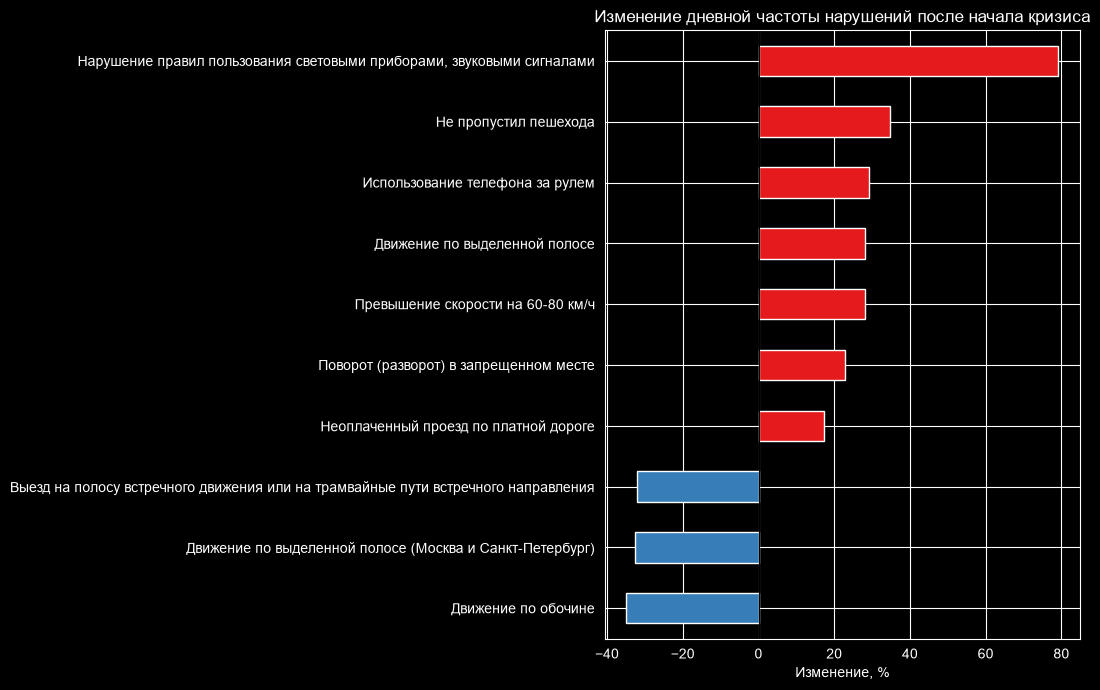

Изображение сохранено: data\processed\offence_change.png


In [73]:
import matplotlib.pyplot as plt

# Проверяем не только число штрафов, но и изменение состава нарушений
offence_period = fines_analysis.assign(
    period=fines_analysis["bill_offence_date"].lt(CRISIS_START).map({True: "before", False: "after"})
)
offence_change = (
    offence_period.groupby(["offence_short_statement", "period"])
    .size()
    .unstack(fill_value=0)
)
days_before = (CRISIS_START - START_DATE).days
days_after = (END_DATE.normalize() - CRISIS_START).days + 1
offence_change = offence_change[(offence_change["before"] >= 30) & (offence_change["after"] >= 30)].copy()
offence_change["change_percent"] = 100 * (
    (offence_change["after"] / days_after)
    / (offence_change["before"] / days_before)
    - 1
)
offence_change = offence_change.reindex(
    offence_change["change_percent"].abs().nlargest(10).index
).sort_values("change_percent")

colors = ["#377eb8" if value < 0 else "#e41a1c" for value in offence_change["change_percent"]]
fig, ax = plt.subplots(figsize=(11, 7))
offence_change["change_percent"].plot.barh(ax=ax, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Изменение дневной частоты нарушений после начала кризиса")
ax.set_xlabel("Изменение, %")
ax.set_ylabel("")
plt.tight_layout()
offence_image = OUTPUT_DIR / "offence_change.png"
plt.savefig(offence_image, dpi=200, bbox_inches="tight")
plt.show()
plt.close()
print("Изображение сохранено:", offence_image)

In [74]:
display(fuel_clean[["order_fuel_volume", "refund_match_status", "refund_type",
                    "physical_fuel_volume_main"]].head())

,order_fuel_volume,refund_match_status,refund_type,physical_fuel_volume_main
0,52.24,not_applicable,none,52.24
1,23.47,not_applicable,none,23.47
2,28.75,not_applicable,none,28.75
3,41.37,not_applicable,none,41.37
4,36.62,not_applicable,none,36.62


## Типы данных

Таблица показывает технический тип, количество пропусков и число уникальных значений каждого столбца.

In [75]:
def describe_data_types(df, table_name):
    return pd.DataFrame({
        "table": table_name,
        "column": df.columns,
        "dtype": df.dtypes.astype(str).values,
        "missing_count": df.isna().sum().values,
        "missing_percent": (df.isna().mean().values * 100).round(2),
        "unique_values": df.nunique(dropna=True).values,
    })


data_types_report = pd.concat([
    describe_data_types(clients, "clients"),
    describe_data_types(fines_clean, "fines"),
    describe_data_types(fuel_clean, "fuel"),
], ignore_index=True)

display(data_types_report)

,table,column,dtype,missing_count,missing_percent,unique_values
0,clients,client_id,string,0,0.00,25675
1,clients,gender,str,42,0.15,2
2,clients,age_type_code,str,2,0.01,4
3,clients,auto_document_id,string,0,0.00,28093
4,clients,auto_mark,str,0,0.00,137
5,clients,auto_year,int64,0,0.00,46
6,clients,engine_type,str,2,0.01,1457
7,clients,price,float64,631,2.23,4381
8,clients,color,str,1408,4.99,442
9,clients,kladr_code,int64,0,0.00,16


## Процентное соотношение штрафов 2025 и 2026 годов

Сравнивается одинаковый период — апрель–август. За 2025 год нет детализации по типам нарушений, поэтому можно сравнить только общее количество штрафов.

In [76]:
fines_2025_columns = [
    "april_2025_fines",
    "may_2025_fines",
    "jun_2025_fines",
    "jul_2025_fines",
    "aug_2025_fines",
]

# Используем уже разрешённую таблицу client×automobile. Конфликтные значения остаются NaN.
fines_2025_by_car = client_auto[PAIR_KEYS + fines_2025_columns].copy()
fines_count_2025 = fines_2025_by_car[fines_2025_columns].sum().sum()

fines_count_2026 = fines_clean.loc[
    fines_clean["bill_offence_date"].between("2026-04-01", "2026-08-31 23:59:59"),
    "bill_id",
].nunique()

year_comparison = pd.DataFrame({
    "year": [2025, 2026],
    "period": ["апрель–август", "апрель–август"],
    "fine_count": [fines_count_2025, fines_count_2026],
})
year_comparison["share_percent"] = (
    100 * year_comparison["fine_count"] / year_comparison["fine_count"].sum()
).round(2)

change_percent = round(100 * (fines_count_2026 / fines_count_2025 - 1), 2)
display(year_comparison)
print(f"Изменение количества штрафов в 2026 году относительно 2025: {change_percent:+.2f}%")

# Сравнение одинаковых месяцев двух лет
month_names = {4: "апрель", 5: "май", 6: "июнь", 7: "июль", 8: "август"}
counts_2025_by_month = fines_2025_by_car[fines_2025_columns].sum()
counts_2025_by_month.index = range(4, 9)
counts_2026_by_month = (
    fines_clean.loc[fines_clean["bill_offence_date"].dt.month.between(4, 8)]
    .groupby(fines_clean["bill_offence_date"].dt.month)["bill_id"]
    .nunique()
    .reindex(range(4, 9), fill_value=0)
)
monthly_comparison = pd.DataFrame({
    "month": [month_names[month] for month in range(4, 9)],
    "fines_2025": counts_2025_by_month.values,
    "fines_2026": counts_2026_by_month.values,
})
monthly_comparison["change_percent"] = (
    100 * (monthly_comparison["fines_2026"] / monthly_comparison["fines_2025"] - 1)
).round(2)
display(monthly_comparison)

,year,period,fine_count,share_percent
0,2025,апрель–август,129048.0,63.88
1,2026,апрель–август,72959.0,36.12


Изменение количества штрафов в 2026 году относительно 2025: -43.46%


,month,fines_2025,fines_2026,change_percent
0,апрель,19923.0,12022,-39.66
1,май,27004.0,16317,-39.58
2,июнь,27035.0,17565,-35.03
3,июль,29263.0,16420,-43.89
4,август,25823.0,10635,-58.82
